## NAME : Anthony Rodrigues
## BRANCH : SE-AIML
## ROLL-NO : 58
## Expt.-9: Apply PCA and LDA to reduce dataset dimensions
## Aim :-To apply Principal Component Analysis (PCA) and Linear Discriminant Analysis (LDA) to reduce the dimensionality of a dataset and visualize the transformed feature space.


In [19]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [20]:
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [21]:
iris=datasets.load_iris()
x = iris.data
y= iris.target

feature_names = iris.feature_names
print(iris.feature_names)
print()
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

['setosa' 'versicolor' 'virginica']


## Part 1 dataset saummary

In [22]:
print("dataset summary table")
print("Number of sample:", x.shape[0])
print(" Number of feature:", x.shape[1])
print("Number of classes:", len(np.unique(y)))
print(feature_names)
print()

dataset summary table
Number of sample: 150
 Number of feature: 4
Number of classes: 3
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']



## Part 2:- feature statistics table(before pca)

In [23]:
df = pd.DataFrame(x, columns=feature_names)
print("feature statistics")
stats_table = pd.DataFrame({
    "Mean": df.mean(),
    "Standard Deviation": df.std()
})
print(stats_table)
print()
print(df.head())
print()

feature statistics
                       Mean  Standard Deviation
sepal length (cm)  5.843333            0.828066
sepal width (cm)   3.057333            0.435866
petal length (cm)  3.758000            1.765298
petal width (cm)   1.199333            0.762238

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2



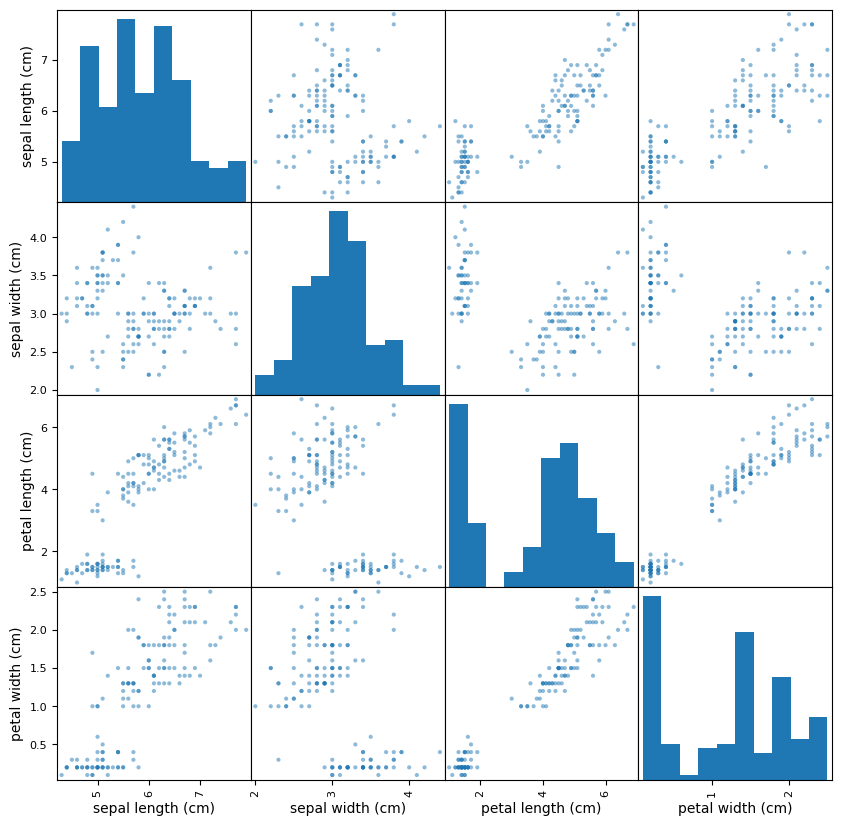

In [24]:
pd.plotting.scatter_matrix(df.iloc[:,0:4], figsize=(10,10), diagonal='hist')
plt.show()

## part 3:- Principal Component Analysis (PCA)

In [25]:
sc = StandardScaler()
x_scaled = sc.fit_transform(x)


In [26]:
pca = PCA (n_components=2)
x_pca = pca.fit_transform(x_scaled)


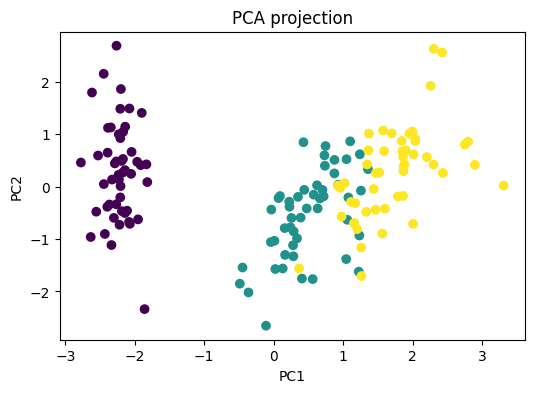

In [27]:
plt.figure(figsize=(6,4))
plt.scatter(x_pca[:,0], x_pca[:,1], c=y)
plt.title("PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



In [28]:
explained_variance = pca.explained_variance_
variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

In [29]:
pca_table = pd.DataFrame({
    "eigenvalue": explained_variance,
    "Explained Varince (%)": variance_ratio*100,
    "Cumulative varfiance (%)": cumulative_variance*100
})

print("PCA VARIANCE TABLE")
print(pca_table)
print()


PCA VARIANCE TABLE
   eigenvalue  Explained Varince (%)  Cumulative varfiance (%)
0    2.938085              72.962445                 72.962445
1    0.920165              22.850762                 95.813207



## PART 4 :-Linear Discriminant Analysis (LDA)

In [30]:
lda =  LinearDiscriminantAnalysis(n_components=2)
x_lda = lda.fit_transform(x_scaled, y)

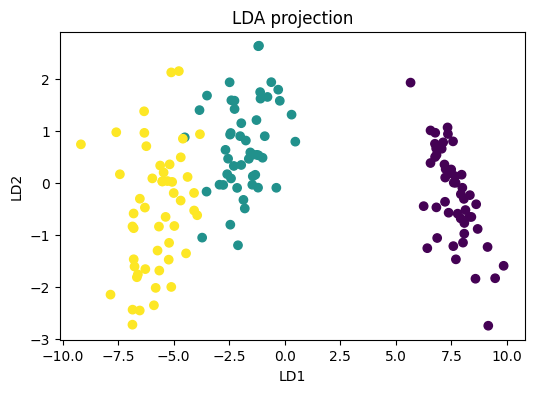

In [31]:
plt.figure(figsize=(6,4))
plt.scatter(x_lda[:,0], x_lda[:,1], c=y)
plt.title("LDA projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()

## PART 5:- CHECKING KNN ACCURACY

In [32]:
x_train , x_test , y_train , y_test = train_test_split(x_scaled, y , test_size=0.3 , random_state=42)
xp_train , xp_test , yp_train , yp_test = train_test_split(x_pca, y , test_size=0.3 , random_state=42)
xl_train , xl_test , yl_train , yl_test = train_test_split(x_lda, y , test_size=0.3 , random_state=42)

In [33]:
model = KNeighborsClassifier()

start = time.time()
model.fit(x_train, y_train)
train_time_original = time.time()-start
y_pred = model.predict(x_test)
acc_original = accuracy_score(y_test , y_pred)

In [34]:
## accuracy pca
start = time.time()
model.fit(xp_train, yp_train)
train_time_pca = time.time()-start
y_pred = model.predict(xp_test)
acc_pca = accuracy_score(yp_test , y_pred)

In [35]:
## accuracy lda
start = time.time()
model.fit(xl_train, yl_train)
train_time_lda = time.time()-start
y_pred = model.predict(xl_test)
acc_lda = accuracy_score(yl_test , y_pred)

In [36]:


# Accuracy table
accuracy_table = pd.DataFrame({
    "Dataset Version": ["Original", "PCA Reduced", "LDA Reduced"],
    "Accuracy": [acc_original, acc_pca, acc_lda],
    "Training Time (seconds)": [train_time_original, train_time_pca, train_time_lda]
})

print("Model Performance Table")
print(accuracy_table)

Model Performance Table
  Dataset Version  Accuracy  Training Time (seconds)
0        Original  1.000000                 0.001788
1     PCA Reduced  0.955556                 0.003013
2     LDA Reduced  1.000000                 0.002336
